In [1]:
# This notebook can be used to process flight files and generate pickled files of correlator+drone data

In [2]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/TONE_july_2025/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_iceboard_files/corr_data/'
gdir = maindir+'TONE_iceboard_files/digital_gains/' 

# define which channels in the data files are useful
crmap = [0,3,4,6,7,8,9]
chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

# from crmap, which indices are autos, which indices are ref crosses
autos = [0,2,4,6]
crosses = [1,3,5]


# define default 'good' frequency for plotting
f_ind = 300 
freqs = np.arange(800,400,-400./1024)
print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))



682.8125


## 1. Find Correspondence between drone flight file and correlator data

In [64]:
# RFI flight
dfile = '20250714T135821Z_WVUc52'
flyfile = 'Jul-14th-2025-10-14AM-Flight-Airdata.csv'

# flights on 07/17
# 
dfile = '20250717T160156Z_WVUc52'
flyfile='Jul-17th-2025-12-16PM-Flight-Airdata.csv'

# 
dfile = '20250717T160156Z_WVUc52'
flyfile='Jul-17th-2025-12-47PM-Flight-Airdata.csv'

#  
dfile = '20250717T160156Z_WVUc52'
flyfile = 'Jul-17th-2025-01-51PM-Flight-Airdata.csv'

#
dfile = '20250717T192717Z_WVUc52'
flyfile = 'Jul-17th-2025-04-07PM-Flight-Airdata.csv'

#
dfile = '20250717T192717Z_WVUc52'
flyfile = 'Jul-17th-2025-04-39PM-Flight-Airdata.csv'

#
dfile = '20250717T234526Z_WVUc52'
flyfile = 'Jul-17th-2025-07-56PM-Flight-Airdata.csv'

#
dfile = '20250717T234526Z_WVUc52'
flyfile = 'Jul-17th-2025-08-47PM-Flight-Airdata.csv'

#
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-11-49AM-Flight-Airdata.csv'

#
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-12-21PM-Flight-Airdata.csv'

# 
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-12-53PM-Flight-Airdata.csv'

#
dfile = '20250718T183125Z_WVUc52'
flyfile = 'Jul-18th-2025-02-55PM-Flight-Airdata.csv'

#
dfile = '20250718T183125Z_WVUc52'
flyfile = 'Jul-18th-2025-03-27PM-Flight-Airdata.csv'

# RFI flight
#dfile = '20250719T000859Z_WVUc52'
#flyfile = 'Jul-18th-2025-08-33PM-Flight-Airdata.csv'

# RFI flight
#dfile = '20250719T183054Z_WVUc52'
#flyfile = 'Jul-19th-2025-02-39PM-Flight-Airdata.csv'

######### LEAVE THIS #############################################
# this handles the wierd directory structure in the iceboard dirs
ddir = cdir+dfile+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+dfile+'_digitalgain/'
print(datadir,gaindir)



/hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250718T201618Z_WVUc52/corr/20250718T201714Z/ /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/digital_gains/20250718T201618Z_WVUc52_digitalgain/


Initializing drone data via Airdata.csv routine: Jul-18th-2025-04-34PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.


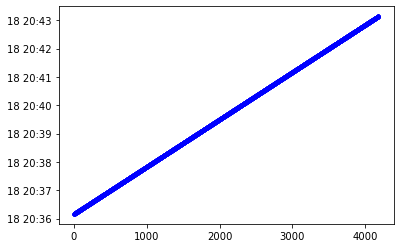

DRONE FLYING FROM (UTC):  2025-07-18 20:36:09.900000+00:00  to (UTC)  2025-07-18 20:43:08.300000+00:00


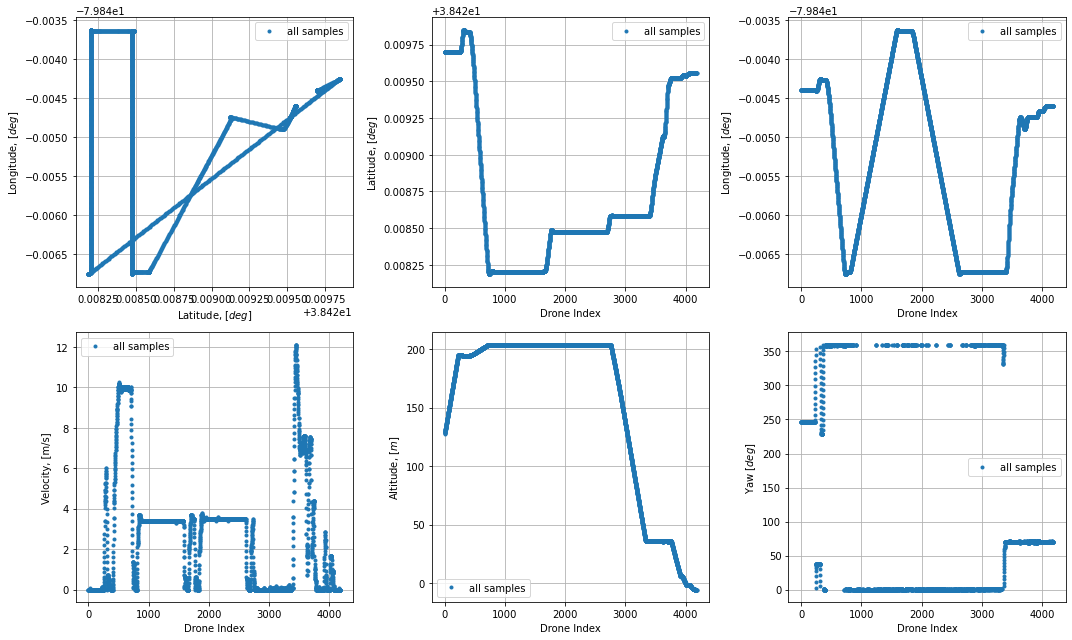

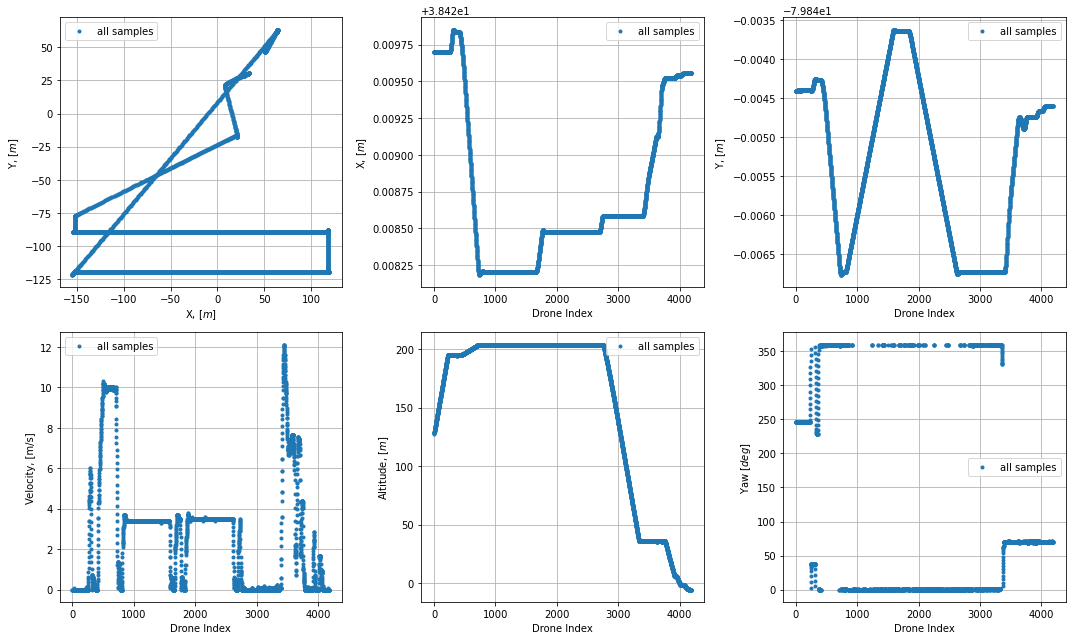

In [65]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=flyfile,site_class=gbosite,tlb=0,tub=-1)

# Plot some drone data to get familiar with the coordinates in the drone class

# Look at time stamps

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

print('DRONE FLYING FROM (UTC): ', dronedata.t_arr_datetime[0], ' to (UTC) ',dronedata.t_arr_datetime[-1])


## Plot lat/long
fig1,[[ax1,ax2,ax3],[ax4,ax5,ax6]]=subplots(nrows=2,ncols=3,figsize=(15,9))
## Plot p0 coordinate origin:
ax1.plot(dronedata.origin[0],dronedata.origin[1],'ro')
ax2.axhline(dronedata.origin[0],c='b')
ax3.axhline(dronedata.origin[1],c='b')
## Title each coordinate subplot:        
ax1.set_title('Lat vs Lon')
ax2.set_title('Lat vs Time')
ax3.set_title('Lon vs Time')
ax4.set_title('Velocity vs Time')
ax5.set_title('Altitude vs Time')
ax6.set_title('Yaw vs Time')
## Specify arrays/vectors to plot in 1,3,4 coordinate subplot
xqtys=[dronedata.latitude,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index]
yqtys=[dronedata.longitude,dronedata.latitude,dronedata.longitude,dronedata.velocity,dronedata.altitude,dronedata.yaw]
xtags=['Latitude, [$deg$]','Drone Index','Drone Index','Drone Index','Drone Index','Drone Index']
ytags=['Longitude, [$deg$]','Latitude, [$deg$]','Longitude, [$deg$]','Velocity, [m/s]','Altitude, [$m$]','Yaw [$deg$]']
for i,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.plot(np.nanmin(xqtys[i]),np.nanmin(yqtys[i]))
    ax.plot(np.nanmax(xqtys[i]),np.nanmax(yqtys[i]))
    autoscalelims=ax.axis()
    ax.clear()
    ax.plot(xqtys[i],yqtys[i],'.',label='all samples')
    ax.set_xlabel(xtags[i])
    ax.set_ylabel(ytags[i])
    ax.grid()
    ax.legend()
    ax.set_xlim(autoscalelims[0],autoscalelims[1])
    ax.set_ylim(autoscalelims[2],autoscalelims[3])
tight_layout()
plt.show()

## Plot local X/Y coords
fig1,[[ax1,ax2,ax3],[ax4,ax5,ax6]]=subplots(nrows=2,ncols=3,figsize=(15,9))
## Plot p0 coordinate origin:
ax1.set_title('X vs Y')
ax2.set_title('X vs Time')
ax3.set_title('Y vs Time')
ax4.set_title('Velocity vs Time')
ax5.set_title('Altitude vs Time')
ax6.set_title('Yaw vs Time')
## Specify arrays/vectors to plot in 1,3,4 coordinate subplot
xqtys=[dronedata.coords_xyz_LC[:,0],dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index]
yqtys=[dronedata.coords_xyz_LC[:,1],dronedata.latitude,dronedata.longitude,dronedata.velocity,dronedata.altitude,dronedata.yaw]
xtags=['X, [$m$]','Drone Index','Drone Index','Drone Index','Drone Index','Drone Index']
ytags=['Y, [$m$]','X, [$m$]','Y, [$m$]','Velocity, [m/s]','Altitude, [$m$]','Yaw [$deg$]']
for i,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.plot(np.nanmin(xqtys[i]),np.nanmin(yqtys[i]))
    ax.plot(np.nanmax(xqtys[i]),np.nanmax(yqtys[i]))
    autoscalelims=ax.axis()
    ax.clear()
    ax.plot(xqtys[i],yqtys[i],'.',label='all samples')
    ax.set_xlabel(xtags[i])
    ax.set_ylabel(ytags[i])
    ax.grid()
    ax.legend()
    ax.set_xlim(autoscalelims[0],autoscalelims[1])
    ax.set_ylim(autoscalelims[2],autoscalelims[3])
tight_layout()
plt.show()    
    

        

In [ ]:
#pu.Animate_Drone_Flight(
#    dronedata, gbosite,
#    step=50,
#    manual_north_shift_m=0,
#    manual_east_shift_m=0,
#    start_time_est="12:16:00",  # optional, EST
#    end_time_est="12:40:00",    # optional, EST
#    start_percent=0.0,
#    end_percent=1,
#    interval=50,
#    center_dish=5,
#    show_dishes=[5, 8]
#)

# # Which channels are interesting?
#fd=h5py.File(datadir+'/0095', 'r')

#print(fd['vis'].shape) # time, freq, product
#print(fd['index_map']['time']['fpga_count'].shape)
#
#for i in [0,1,4,5]:#np.arange(0,10):
#    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
#plt.legend()
#plt.plot()
#plt.show()
#
#
#for i in [2,3,6,7,8,9]:#np.arange(0,10):
#    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
#plt.legend()
#plt.ylim(0,10000)
#plt.plot()

# channels which should have some signal: [0,3,4,6,7,8,9]

In [53]:
# drone start time - HAS TO BE IN LOCAL TIME (not UTC)
cont, nxt = tu.Find_File_And_Next("2025-07-18 15:29:16", datadir)
for entry, label in zip([cont, nxt], ["Containing", "Next"]):
    if entry:
        print(f"{label} file {entry['file']:04d}:")
        print(f"   UTC range: {entry['UTC_start']} – {entry['UTC_end']}")
        print(f"   EST range: {entry['EST_start']} – {entry['EST_end']}")
        
# drone end time, HAS TO BE IN LOCAL TIME (not UTC)        
cont, nxt = tu.Find_File_And_Next("2025-07-18 15:48:38", datadir)

for entry, label in zip([cont, nxt], ["Containing", "Next"]):
    if entry:
        print(f"{label} file {entry['file']:04d}:")
        print(f"   UTC range: {entry['UTC_start']} – {entry['UTC_end']}")
        print(f"   EST range: {entry['EST_start']} – {entry['EST_end']}")
        
# check if you want: 
#times = tu.Get_File_Times(261, datadir)   # works with 202 or '202' or '0202'
#print(times["UTC_start"], times["EST_start"])

#times = tu.Get_File_Times(380, datadir)   # works with 202 or '202' or '0202'
#print(times["UTC_start"], times["EST_start"])

Containing file 0315:
   UTC range: 2025-07-18 19:29:12.855178+00:00 – 2025-07-18 19:29:23.556043+00:00
   EST range: 2025-07-18 15:29:12.855178+00:00 – 2025-07-18 15:29:23.556043+00:00
Next file 0316:
   UTC range: 2025-07-18 19:29:23.592322+00:00 – 2025-07-18 19:29:34.293402+00:00
   EST range: 2025-07-18 15:29:23.592322+00:00 – 2025-07-18 15:29:34.293402+00:00
Containing file 0423:
   UTC range: 2025-07-18 19:48:32.492992+00:00 – 2025-07-18 19:48:43.188897+00:00
   EST range: 2025-07-18 15:48:32.492992+00:00 – 2025-07-18 15:48:43.188897+00:00
Next file 0424:
   UTC range: 2025-07-18 19:48:43.230585+00:00 – 2025-07-18 19:48:53.927235+00:00
   EST range: 2025-07-18 15:48:43.230585+00:00 – 2025-07-18 15:48:53.927235+00:00


In [54]:
# Load in some correlator data
## Combine drone and correlator data

print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                            Gain_Directory=gaindir,site_class=gbosite,use_ctime=True,
                            Load_Gains=False,crossmap=crmap,Data_File_Index=[315,424])

    
print('end time: ', datetime.datetime.now())

print(corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

start time:  2025-09-25 09:58:24.139691
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250718T183125Z_WVUc52/corr/20250718T183250Z/
  --> Arrays initialized with shape (109, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0423/0423
  --> Finished. Reshaping arrays.
end time:  2025-09-25 10:00:18.600384
2025-07-18 19:29:12.855178+00:00 2025-07-18 19:48:43.191823+00:00


2025-07-18 19:29:16.900000+00:00 2025-07-18 19:48:38.800000+00:00
2025-07-18 19:29:12.855178+00:00 2025-07-18 19:48:43.191823+00:00


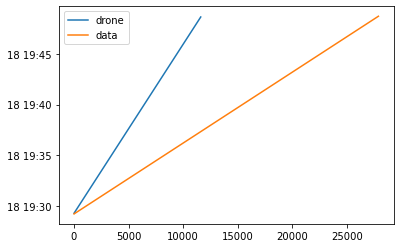

In [55]:
print(dronedata.t_arr_datetime[0],dronedata.t_arr_datetime[-1])
print(corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

# check time correspondence
plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()



In [56]:
# Match drone and correlator data together

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)

print(concatdata.V_cross.shape)

(27904, 1024, 7)


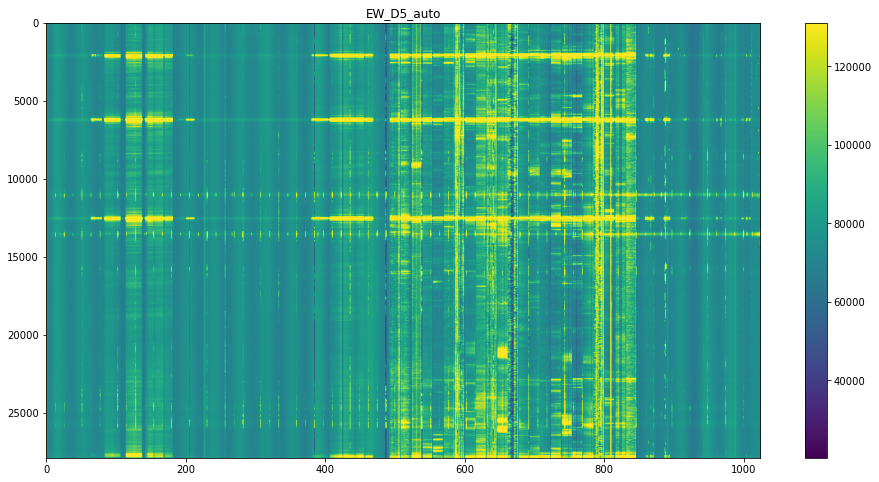

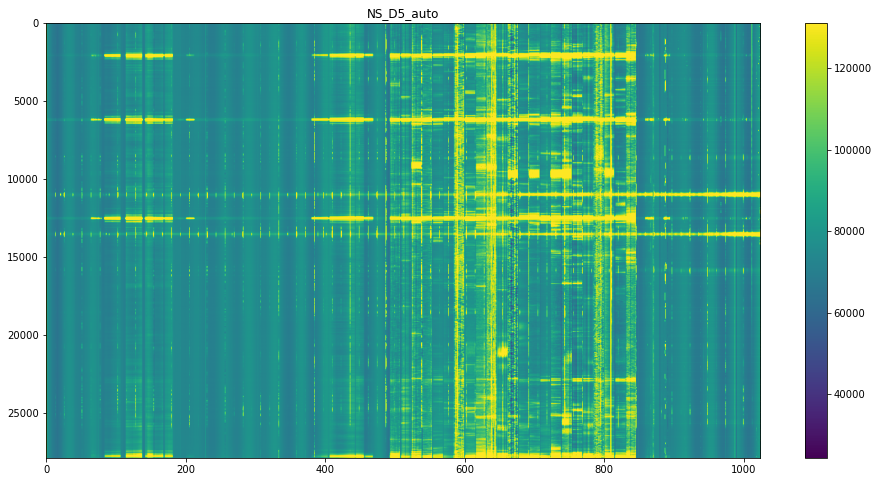

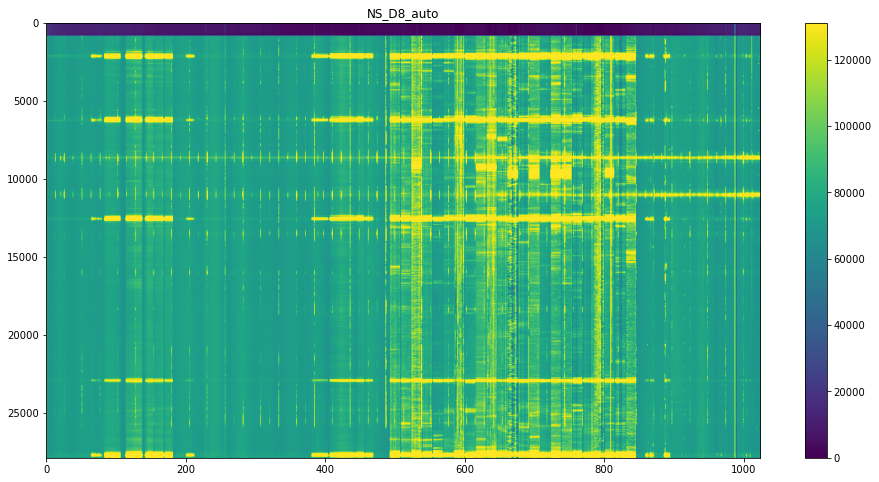

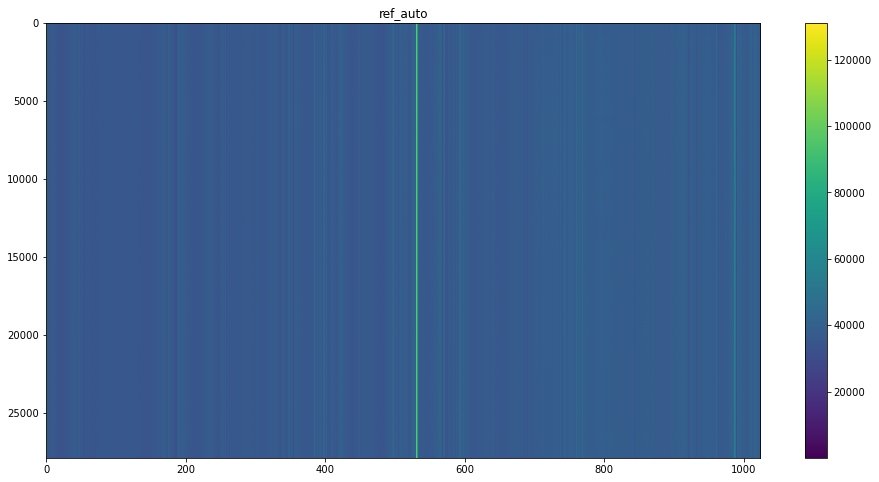

In [57]:
# Check some waterfalls, etc

for j in autos:
    fig=figure(figsize=(16,8))
    plt.imshow(abs(concatdata.V_cross[:,:,j]),aspect='auto')
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

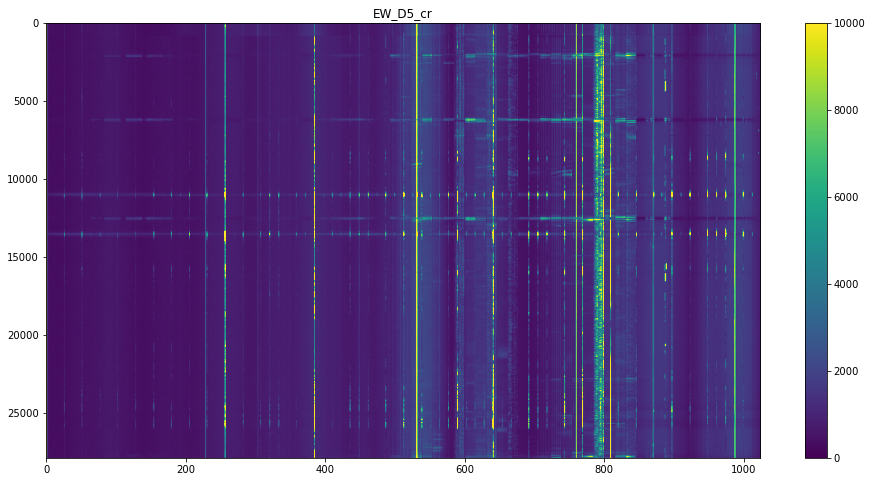

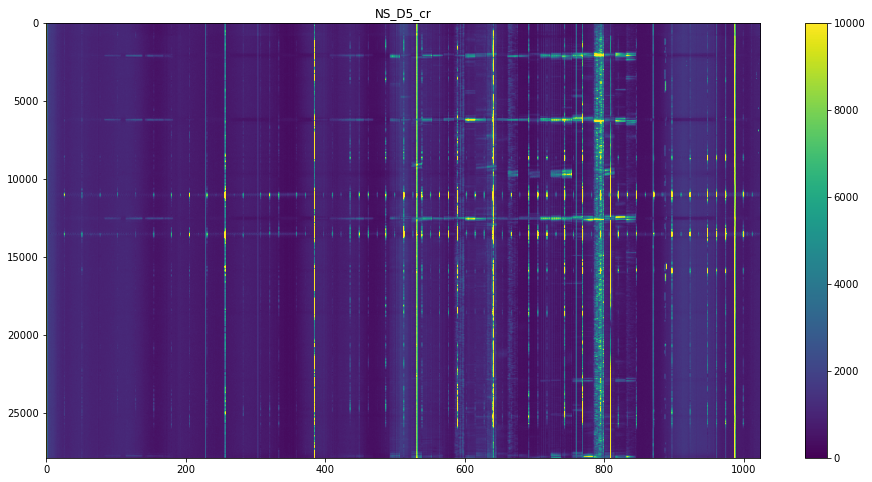

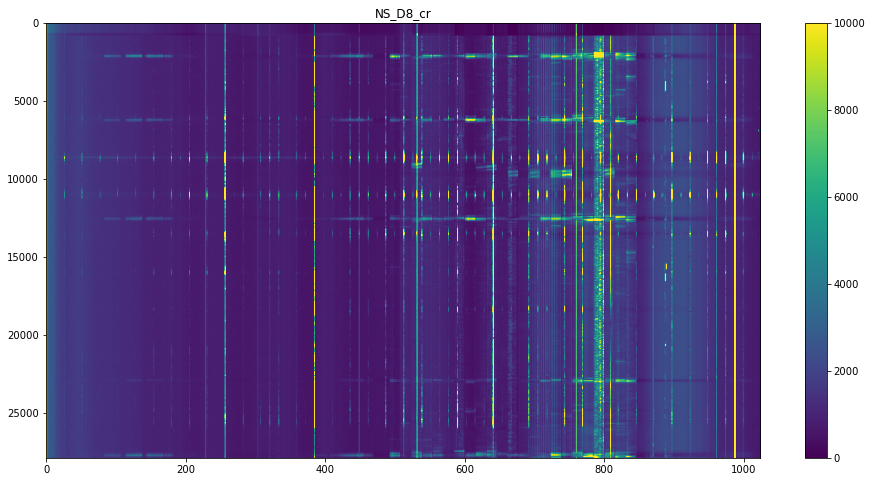

In [58]:
for j in crosses:
    fig=figure(figsize=(16,8))
    plt.imshow(abs(concatdata.V_cross[:,:,j]),aspect='auto',vmin=0,vmax=10000)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

In [ ]:
mean_perch = np.median(abs(concatdata.V_cross),axis=0) # time, freq,ch
max_perch = np.max(abs(concatdata.V_cross),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.show()

In [ ]:
for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],c=concatdata.V_cross[:,f_ind,j])
    plt.colorbar()
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.title(chnames[j])
    plt.show()

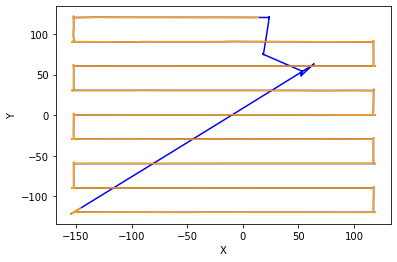

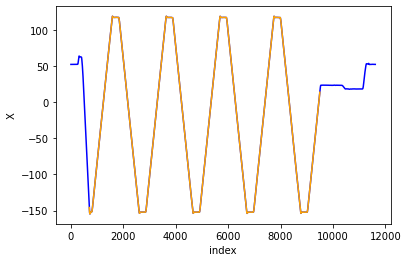

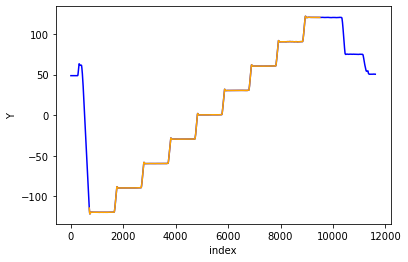

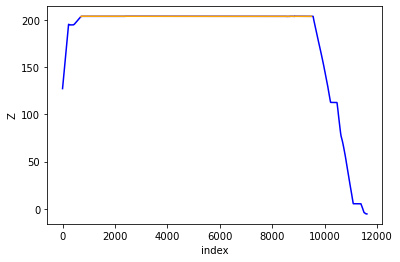

In [62]:
# Let's pick most interesting drone data region, given the file selection above

tlb = 700
tub = 9500
indrange = np.arange(tlb,tub)


plt.plot(dronedata.coords_xyz_LC[:,0],dronedata.coords_xyz_LC[:,1],color='blue')
plt.plot(dronedata.coords_xyz_LC[tlb:tub,0],dronedata.coords_xyz_LC[tlb:tub,1],color='orange')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

plt.plot(dronedata.coords_xyz_LC[:,0],color='blue')
plt.plot(indrange,dronedata.coords_xyz_LC[tlb:tub,0],color='orange')
plt.xlabel('index')
plt.ylabel('X')
plt.show()

plt.plot(dronedata.coords_xyz_LC[:,1],color='blue')
plt.plot(indrange,dronedata.coords_xyz_LC[tlb:tub,1],color='orange')
plt.xlabel('index')
plt.ylabel('Y')
plt.show()

plt.plot(dronedata.coords_xyz_LC[:,2],color='blue')
plt.plot(indrange,dronedata.coords_xyz_LC[tlb:tub,2],color='orange')
plt.xlabel('index')
plt.ylabel('Z')
plt.show()  

In [63]:
# Let's convert that into the indices for the correlator data:
dt = corrdata.t_arr_datetime[1] - corrdata.t_arr_datetime[0]

# Lets find the index that corresponds to the start of the interesting drone region
if dronedata.t_arr_datetime[tlb] > concatdata.t_arr_datetime[0]:
    tclb = int((dronedata.t_arr_datetime[tlb] - concatdata.t_arr_datetime[0])/dt) - 1
else: tclb = 0
    
print(tclb,concatdata.t_arr_datetime[tclb],dronedata.t_arr_datetime[tlb])

# Lets find the index that corresponds to the end of the interesting drone region
if dronedata.t_arr_datetime[tub] <  concatdata.t_arr_datetime[-1]:
    tcub = int((dronedata.t_arr_datetime[tub] - concatdata.t_arr_datetime[0])/dt) + 1
else: tcub = -1
print(tcub,concatdata.t_arr_datetime[tcub],dronedata.t_arr_datetime[tub])

# These tclb,tcub bounds are used for plotting/analysis, but not reading in the data
# the concat class will extrapolate the drone data to the entire region even though
# there is no useful drone data there. 

1764 2025-07-18 19:30:26.842701+00:00 2025-07-18 19:30:26.900000+00:00
22756 2025-07-18 19:45:07.310996+00:00 2025-07-18 19:45:07.300000+00:00


## 2. Capture in the yaml file - then can run everything below without above
#(Once it is in a yaml file, the above cells do not need to be run)

In [69]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]

for f,fly in enumerate(flights):
    fly = flights[f]
    tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
    tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
    cdat = documents["flight_info"]["cdats"][f]
    tclb = documents["flight_info"]["tclbs"][f]
    tcub = documents["flight_info"]["tcubs"][f]
    fmax = documents["flight_info"]["fmaxes"][f]
    fmin = documents["flight_info"]["fmins"][f]
    descrip = documents["flight_info"]["desc"][f]
    pols = documents["flight_info"]["pols"][f]
    print(fly, cdat, tlb, tub, tclb, tcub, fmin,fmax,descrip,pols)

Jul-14th-2025-10-14AM-Flight-Airdata.csv 20250714T135821Z_WVUc52 0 -1 0 -1 94 229 NS N
Jul-17th-2025-12-16PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11700 1846 28077 87 202 NS N
Jul-17th-2025-12-47PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 750 11300 1816 26971 261 380 NS N
Jul-17th-2025-01-51PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11600 1894 27884 616 730 NS E
Jul-17th-2025-04-07PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 800 11000 2095 26418 228 348 NS E
Jul-17th-2025-04-39PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 700 11500 1864 27615 408 520 EW N
Jul-17th-2025-07-56PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1900 27651 63 188 NW N
Jul-17th-2025-08-47PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1826 27582 348 471 NW N
Jul-18th-2025-11-49AM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1824 27695 158 284 NW N
Jul-18th-2025-12-21PM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1915 27785 340 461 EW E
Jul-18th-2025-12-53PM-Fl

In [16]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]

for f,fly in enumerate(flights):
    print(f,flights[f],descrip[f])

# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml
f = 8


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print(fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

0 Jul-14th-2025-10-14AM-Flight-Airdata.csv NS
1 Jul-17th-2025-12-16PM-Flight-Airdata.csv NS
2 Jul-17th-2025-12-47PM-Flight-Airdata.csv NS
3 Jul-17th-2025-01-51PM-Flight-Airdata.csv NS
4 Jul-17th-2025-04-07PM-Flight-Airdata.csv NS
5 Jul-17th-2025-04-39PM-Flight-Airdata.csv EW
6 Jul-17th-2025-07-56PM-Flight-Airdata.csv NW
7 Jul-17th-2025-08-47PM-Flight-Airdata.csv NW
8 Jul-18th-2025-11-49AM-Flight-Airdata.csv NW
9 Jul-18th-2025-08-33PM-Flight-Airdata.csv NS
10 Jul-19th-2025-02-39PM-Flight-Airdata.csv NS
Using data directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250718T152104Z_WVUc52/corr/20250718T152228Z/
Using gain directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/digital_gains/20250718T152104Z_WVUc52_digitalgain/
Jul-18th-2025-11-49AM-Flight-Airdata.csv 11600 750 1824 27695 20250718T152104Z_WVUc52 158 284


Initializing drone data via Airdata.csv routine: Jul-17th-2025-01-51PM-Flight-Airdata.csv
  --> Skipping rows 1 to 1199 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-17 17:55:36.900000+00:00 2025-07-17 18:13:46.800000+00:00


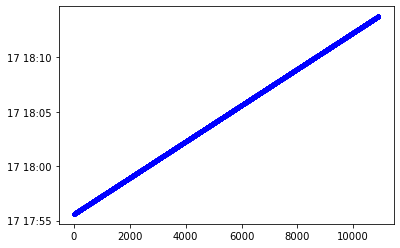

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


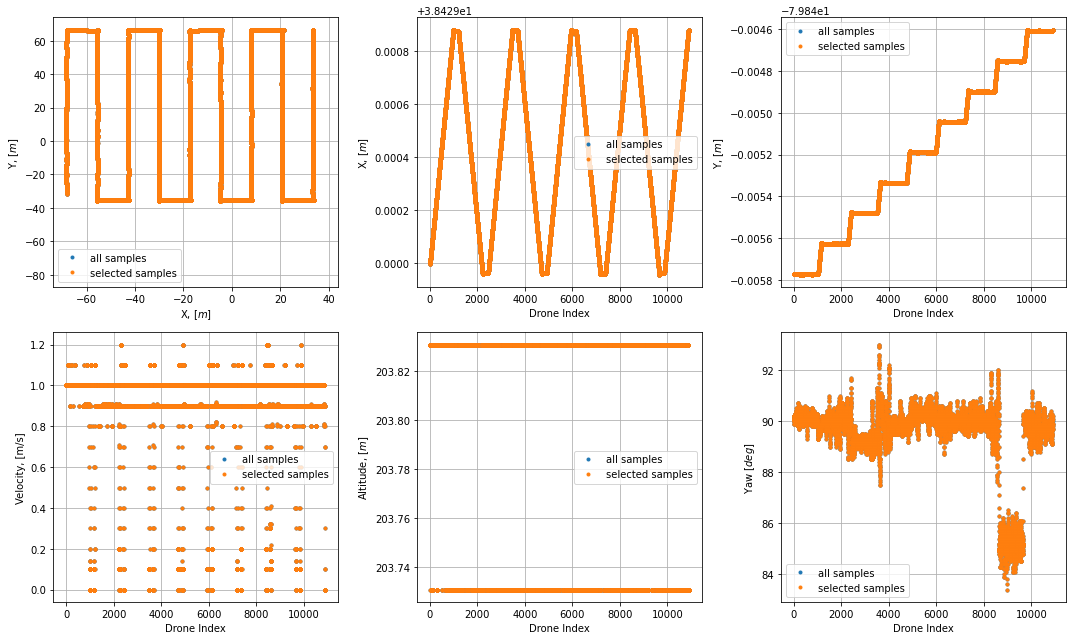

In [4]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

start time:  2025-09-23 14:36:39.539334
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250717T160156Z_WVUc52/corr/20250717T160253Z/
  --> Arrays initialized with shape (114, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0729/0729
  --> Finished. Reshaping arrays.
end time:  2025-09-23 14:37:04.527492


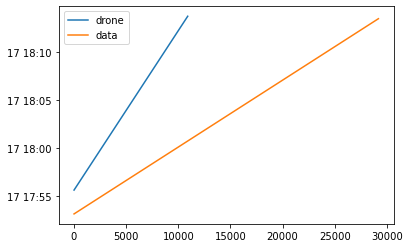

In [5]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=True,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmax)])

#corrdata=corr.Corr_Data(Data_Directory=datadir,
#                    Gain_Directory=gaindir,site_class=gbosite,
#                    Load_Gains=True,use_ctime=True,
#                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmin)+1])


    
print('end time: ', datetime.datetime.now())

# putting checks in one cell now that I know I've mostly figured out the flight/corr file correspondence
# This checks I copied and pasted ok :)

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [6]:
# Match drone and correlator data together, and plot a few frequencies

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)


In [ ]:
## Bunches of plots to quickly look at the data
plotthis = False

if plotthis:
    print('Beam maps without any time correction or pulse calculation')
    for j in np.arange(0,len(crmap)):
        plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
                c=abs(concatdata.V_cross[:,f_ind,j]))
        plt.colorbar()
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.title(chnames[j])
        plt.show()
    
    print('Plot the gains')
    # lets check gain application
    print(gaindir)
    gainfile=os.listdir(gaindir)[0]
    fg = h5py.File(gaindir+gainfile, 'r')
    gain_coeffs=fg['gain_coeff'][0] 
    gain_exp=fg['gain_exp'][0]
    digital_gain=fg['gain_coeff'][0] 
    digital_gain*=np.power(2,fg['gain_exp'][0])[np.newaxis,:]

    for j in np.arange(0,len(digital_gain[0,:])):
        plt.semilogy(freqs,digital_gain[:,j],label=str(j))
    plt.legend()
    plt.show()

    # plot waterfalls 

    print('Plotting waterfalls of autocorrelations')
    # waterfall of autos
    vmin=-100
    vmax=-92
    for j in autos:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
    
    print('plotting waterfalls of dish x reference')
    # waterfall of crosses
    vmin=-140
    vmax=-100
    for j in crosses:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()

In [ ]:
mean_perch = np.std(abs(concatdata.V_cross),axis=0) # time, freq,ch
max_perch = np.max(abs(concatdata.V_cross),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,max_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.ylim(0,1E-9)
plt.title('MAX value across time')
plt.show()

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.ylim(0,0.2E-9)
plt.title('MEAN value across time')
plt.show()

In [ ]:
## Let's find the time bounds for a central transit, and examine those bounds when we solve for the source pulses:

print(concatdata.V_cross.shape)
f_ind = 300
print(freqs[f_ind])

plb = 9000
pub = 11000

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_index[:],abs(concatdata.V_cross[:,f_ind,j]),'.')
    plt.xlim(tclb,tcub)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.show()

In [ ]:
print(concatdata.V.shape)

In [ ]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.
concatdata.traceback=False
print('start time: ', datetime.datetime.now())
concatdata.Extract_Source_Pulses(Period=0.99999e6,Dutycycle=0.5e6,t_bounds=[0,-1],f_ind=f_ind, use_ref_channel=3)

print('end time: ', datetime.datetime.now())

In [ ]:
# aside to look at the span, on, and off indices in more detail

chind = 6
t_cut = concatdata.inds_on
t_span = concatdata.inds_span
t_off = concatdata.inds_off
N = len(t_cut)
N2 = int(N/2)
print(len(t_cut),len(t_span),len(t_off))
plt.figure(1,figsize=(10,10))

plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.xlim(concatdata.t_arr_datetime[t_cut[N2]],concatdata.t_arr_datetime[t_cut[N2+300]])
plt.legend()
plt.show()

In [ ]:
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],abs(concatdata.V_cross[t_cut,f_ind,j]),'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],abs(concatdata.V_cross[t_span,f_ind,j]),'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],abs(concatdata.V_cross[t_off,f_ind,j]),'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

In [ ]:
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,j].real,'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,j].real,'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,j].real,'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()
    
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,j].imag,'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,j].imag,'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,j].imag,'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title('IMAG '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

In [ ]:
for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross[t_cut,f_ind,j]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    plt.colorbar()
    plt.show()

In [ ]:
cmap = cm.jet
cmap.set_bad('red') # Set NaNs to white

# waterfall of autos
print('Plotting waterfalls of autocorrelations')
# waterfall of autos
vmin=-100
vmax=-92
for j in autos:
    fig=figure(figsize=(16,8))
    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

print('plotting waterfalls for crosses')
# waterfall of crosses
vmin=-140
vmax=-100
for j in crosses:
    fig=figure(figsize=(16,8))
    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

In [ ]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
concatdata.Perform_Background_Subtraction(window_size=15)

In [ ]:
print(concatdata.V_cross.shape)
print(concatdata.V_bgsub.shape)
print(concatdata.V_cross_bgsub.shape)
print(f_ind)
print(concatdata.t_index)

j=0
print(abs(concatdata.V_cross[t_cut,f_ind,j]))
print(abs(concatdata.V_cross[t_off,f_ind,j]))
print(concatdata.V_cross_bgsub[t_cut,f_ind,j])

nan_count_numpy = np.count_nonzero(np.isnan(concatdata.V_cross_bgsub[t_cut,f_ind,j]))
print(f"NaN count in NumPy array: {nan_count_numpy}")

In [ ]:
f_ind = 300
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross_bgsub[t_cut,f_ind,j].real,'b.')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()
    
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross_bgsub[t_cut,f_ind,j].imag)
    plt.title('IMAG '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

In [ ]:
cmap = cm.Greys
cmap.set_bad('blue') # Set NaNs to white

lb = 4400
ub = 5000#4800

lf = 0
uf = 1021

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    for f in np.arange(uf-10,uf):
        plt.plot(concatdata.V_cross_bgsub[t_cut[lb:ub],f,j].real,label=str(f))
    plt.legend()
    plt.title(chnames[j])
    plt.show()


    #fig=figure(figsize=(16,8))
    #plt.imshow(
    #    np.sign(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real)*10*np.log10(abs(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real)),
    #       cmap=cmap,aspect='auto',vmin=-110,vmax=110)
    #plt.title(chnames[j])
    #plt.colorbar()
    #plt.show()
    
    fig=figure(figsize=(16,8))
    plt.imshow(
        np.sign(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real),
           cmap=cmap,aspect='auto',extent=[freqs[lf],freqs[uf],ub,lb])
    plt.title(chnames[j])
    plt.colorbar()
    plt.axvline(freqs[300],color='red')
    plt.show()


In [ ]:
10*0.39/7

In [ ]:
peak = 4600
ca = ['blue','purple','orange','brown']
lf = 250
uf = 500

fig=figure(figsize=(16,8))
for i,j in enumerate(autos):
    plt.plot(freqs[lf:uf],np.sign(concatdata.V_cross_bgsub[t_cut[peak],lf:uf,j].real)+0.1*j,
             color=ca[i],marker='.',linestyle='None',label=chnames[j])
    plt.plot(freqs[300],np.sign(concatdata.V_cross_bgsub[t_cut[peak],300,j].real)+0.1*j,
             color=ca[i],marker='s',ms=10)

tenpeaks = np.arange(freqs[uf],freqs[lf],10)
for tenp in tenpeaks:
    plt.axvline(tenp,color='black',linestyle='--')
plt.legend()
plt.title(chnames[j])
#plt.xlim(250,500)
plt.show()

In [ ]:
j=2
fig=figure(figsize=(16,8))
plt.plot(concatdata.V_cross[t_cut,f_ind,j].real,'b.',label='on')
plt.plot(concatdata.V_cross[t_span,f_ind,j].real,'gx',label='span')
plt.plot(concatdata.V_cross[t_off,f_ind,j].real,'r.',label='off')
plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
plt.legend()
plt.show()

#fig=figure(figsize=(16,8))
#plt.plot(concatdata.V_cross[:,f_ind,j].real,'b.',label='on')
#plt.plot(concatdata.V_cross_bg[:,f_ind,j].real,'gx',label='bg')
#plt.plot(concatdata.V_cross_bgsub[:,f_ind,j].real,'r.',label='bgsub')
#plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
##plt.xlim(4400,4800)
#plt.xlim(10000,11000)
#plt.legend()
#plt.show()

In [ ]:
p=1
plt.scatter(concattest0825.drone_xyz_LC_interp[t_cut,0],concattest0825.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concattest0825.V_bgsub[t_cut,f,p]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(-40,40)
#plt.ylim(-40,40)
plt.colorbar()
plt.show()

In [ ]:
## OBJECTIVE 5C: concat Function: Synchronization_Function

## This function finds the absolute timing shift between the dji data from the drone and the correlator
    ## We will be loading t_delta_dji from the config file to save some time!
    ## This function only works if the source was pulsed and if V_bgsub was created using background subtraction.
    ## This function works by zooming into the gaussian main beam and removing saturated data points...
## To run, you must give the following:
    ## inputcorr  = the corr class used in the concat
    ## inputdrone = the drone class used in the concat
## The optional parameters and their default values are listed below:
    ## coarse_params=[-10.0,10.0,0.2]    = the min,max,step parameters for the coarse time offset array
    ## fine_params=[-0.5,0.5,0.01]       = the min,max,step parameters for the fine time offset array
    ## chans=np.arange(0,2)              = the channels to fit. 0,1 gives us each polarization
    ## freqs=np.arange(100,1024,150)     = the min,max,step parameters for the freq array axis
    ## FMB_coordbounds=[50.0,50.0,150.0] = the cartesian coords we restrict around the main beam
        # x within +/- 50m from dish center in Local Cartesian (LC)
        # y within +/- 50m from dish center in Local Cartesian (LC)
        # z > 150m from dish center in Local Cartesian (LC)
    ## FMB_ampbound=0.999                = amplitude percentile threshold for saturation... 
        # time indices where the amplitude exceeds 0.999*maximum value are excluded because they are saturated

concattest0825.Synchronization_Function(inputcorr=corrtest0825,inputdrone=dronetest0825,
                                        coarse_params=[-5.0,5.0,0.2],
                                        FMB_coordbounds=[30.0,30.0,150.0],
                                        FMB_ampbound=0.999)

## Since we are loading from the config, we get to skip an iterative loop and just take the solution and apply it.
    ## The verification plot shown is hidden when traceback==False is set in the concat initialization
    ## Look closely at the verification plots to see which channel appears to be the co-pol (channel 1)
    ## In the bottom 2 panels, compare the fit result (white gaussian) to the data points (in color)
        ## We are omitting the saturated points to find the REAL max value, instead of squashing our peak
        ## If we are satisfied with this fit, we should try to save the parameters we found...

In [ ]:
plt.scatter(concattest0825.drone_xyz_LC_interp[t_cut,0],concattest0825.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concattest0825.V_bgsub[t_cut,f,p]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(-40,40)
#plt.ylim(-40,40)
plt.colorbar()
plt.show()

In [ ]:
concattest0825.Distance_Compensation(f_ind=900,plot_channels=[0])

In [ ]:
## OBJECTIVE 5D: concat Function: Export_yaml

## When we have results we want to save, we should export our results to a config file for future use:
    ## The file will be written to the directory stated when the concat class was initialized.
    ## If a concat config yaml file already exists, a new version will be saved.
## Uncomment this if you want to export a config file... 
concattest0825.Export_yaml()

In [ ]:
p=1
f = 896#768#896#832

for f in np.arange(512,1024,100):
    print(f)
    plt.scatter(concattest0825.drone_xyz_LC_interp[:,0],concattest0825.drone_xyz_LC_interp[:,1],
            c=10*np.log10(concattest0825.V[:,f,p]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.colorbar()
    plt.show()

#plt.hist(concattest0825.V[:,f,p],range=[-1E-11,1E-11],bins=100)
#plt.show()

In [ ]:
## OBJECTIVE 5E: concat Function: Main_Beam_Fitting

## Now we can do some analysis, since we have synchronized useful data. We can begin by fitting the main beam:
    ## You can specify the directory where you want the fit params to be output:
    ## fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/'
    ## This one sometimes takes a while, feel free to get a coffee or something.
concattest0825.Main_Beam_Fitting(fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/',
                                 FMB_ampbound=0.999,
                                 Vargs='bgsub')

In [ ]:
# copy and paste the file list above to make a plot
## this is your first glance at whether the Gaussian fits make sense across frequency for all channels
## these are grouped by polarization: small dots are one pol, big dots are the other
filelist=['FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz']
pu.plot_MBG_fits(filelist,cmp='gnuplot2')

In [ ]:
print(fits['G_popt'].shape)

In [ ]:
markers = ['s','v','^','>','P','x','+','o']
colors=['red','orange','yellow','green','blue','purple','pink']
import glob

fits = np.load('/hirax/GBO_Analysis_Outputs/main_beam_fits/FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz')
pols=[0,2,8,10,14]
freqs = np.arange(800,400,-400/1024)

# amp
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,0],markersize=4,color=colors[pp],label=str(p))
plt.title('Amplitude')
plt.legend()
plt.ylim(0,1.5E-7)
plt.show()

# X width
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,2],markersize=4,marker='.',color=colors[pp],linestyle='None',label=str(p))
plt.title('X width')
plt.legend()
plt.ylim(4,15)
plt.show()

# Y width
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,4],markersize=4,marker='.',linestyle='None',color=colors[pp],label=str(p))
plt.title('Y width')
plt.legend()
plt.ylim(4,17)
plt.show()

# X center
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,1],markersize=4,color=colors[pp],label=str(p))
plt.title('X center')
plt.legend()
#plt.ylim(4,14)
plt.show()

# Y center
fig = plt.figure(figsize=(8,6))
for pp,p in enumerate(pols):
    plt.plot(freqs,fits['G_popt'][p,:,3],markersize=4,color=colors[pp],label=str(p))
plt.title('Y center')
plt.legend()
#plt.ylim(4,14)
plt.show()


In [ ]:
# write out to a pickle file, name is autogenerated in the Smallify class

thingy = rc.Smallify(concattest0825)
print(thingy.tmppath)
with open(thingy.tmppath, 'wb') as outp:
    pickle.dump(thingy, outp, pickle.HIGHEST_PROTOCOL)
print('DONE')

In [ ]:
radfile = '/hirax/GBO_Analysis_Outputs/FLY625_20210826T182904Z_ver_20230905T125440_concat.pkl'
radfile = thingy.tmppath
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    ptest = pickle.load(inp)



In [ ]:

plt.scatter(ptest.drone_xyz_LC_interp[:,0],ptest.drone_xyz_LC_interp[:,1],c=10*np.log10(ptest.V_bgsub[:,900,p]), cmap='gnuplot2')

In [ ]:
print(len(ptest.V_bgsub[:,0,0]),len(ptest.V_bgsub[0,:,0]),len(ptest.V_bgsub[0,0,:]))
print(len(ptest.V_bg[:,0,0]),len(ptest.V_bg[0,:,0]),len(ptest.V_bg[0,0,:]))

In [ ]:
## let's try some operations to save it

# write a reduced class
[a for a in dir(ptest) if not a.startswith('__')] # prints out all attrs

In [ ]:
################################################
################# DEPRECATED ###################
################################################
##### Below is deprcated, keep as a record #####
################################################
################# DEPRECATED ###################
################################################
#
## Checking if the flight and numbers correspond from what I've written in the spreadsheet#
#
## 1. You will want to exclude regions of the flight that contain the drone moving to/from home.
### a. read the whole file in (tlb, tub to 0,-1)
### b. read in the flight
### c. plot (I suggest in a separate cell) the flight, examine with various tlb, tub bounds until you've 
###    excluded the stuff you don't want
### d. copy the tlb, tub into a vector under the flight for posterity [someday, a yaml, but not today]
### e. read in the drone file again, this time setting the tlb, tub to something
### this last step is crucial, there isn't a better way to restrict the rest of the analysis/pickling afterwards
#
#[tlb,tub]=[0,-1] # default values to read in full array
#
#config_directory="/hirax/GBO_Analysis_Outputs/concat_config_files/"
#tclb,tcub=[8500,20000]
#
#
##fly = '533'
##cdat= '20210826T182904Z'
##[tlb,tub]=[1900,11000]
#
##fly = '534'
##cdat = '20210826T185621Z'
##[tlb,tub]=[1650,10000]
#
##fly = '535'
##cdat = '20210826T192056Z'
##[tlb,tub]=[2000,9500]
#
##fly = '536' # this flight, careful to read in only corr files 0-95
##cdat = '20210826T195003Z'
##[tlb,tub]=[1600,10100]
#
##fly='613'
##cdat='20211021T144905Z'
##[tlb,tub]=[5300,13800]
#
##fly = '615'
##cdat = '20211021T151650Z'
##[tlb,tub]=[3200,10600]
#
##fly = '618'
##cdat = '20211021T183430Z'
##[tlb,tub]=[7300,15000]
#
##fly = '619'
##cdat = '20211021T185805Z'
##[tlb,tub]=[3000,11400]
#
##fly = '620'
##cdat = '20211021T192212Z'
##[tlb,tub]=[1550,9400]
#
##fly = '623'
##cdat = '20211021T203206Z'
##[tlb,tub]=[1700,9500]
#
##fly = '624'
##cdat = '20211021T205659Z'
##[tlb,tub]=[2400,10200]
#
##fly = '625'
##cdat = '20211021T214028Z'
##[tlb,tub]=[2900,12000]
#
##fly = '646'
##cdat = '20211022T183659Z'
##[tlb,tub]=[7500,16100]
#
##fly = '647'
##cdat = '20211022T185749Z'
##[tlb,tub]= [1600,10400]
#
##fly = '648'
##cdat = '20211022T191922Z'
##[tlb,tub]=[2700,10700]
#
##fly = '649'
##cdat = '20211022T194308Z'
##[tlb,tub]=[1500,9900]
#
#if int(fly) < 537:
#    mdir='/hirax/GBO_Aug_2021/TONE_ACQ/'+cdat+'_yale_drone/corr/' # August 2021
#    gaindir='/hirax/GBO_Aug_2021/TONE_ACQ/digital_gains/'+cdat+'_yale_drone_yale_digitalgain/' # August 2021
#else:
#    mdir='/hirax/GBO_Oct_2021/TONE_ACQ/'+cdat+'_yale_drone/corr/' # Oct 2021
#    gaindir='/hirax/GBO_Oct_2021/TONE_ACQ/digital_gains/'+cdat+'_yale_drone_yale_digitalgain/' # Oct 2021
#
#sdir = os.listdir(mdir)[0]
#datadir=mdir+sdir+'/'
#print(sdir, datadir,gaindir)
#    
#dronedir='/hirax/all_drone_data/datcon_csv/'
#dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='FLY'+fly+'.csv',site_class=gbosite,tlb=tlb,tub=tub)
#
#print('DONE reading in drone data')
#print(dronetest0825.t_arr_datetime[0], dronetest0825.t_arr_datetime[-1])
#
################################################
################# DEPRECATED ###################
################################################
##### Above is deprcated, keep as a record #####
################################################
################# DEPRECATED ###################
################################################
